In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

# Quiz
- (1) 데이터 수집: 네이버 Open API로 '경주여행', '전주여행' 블로그글 각 500건 수집 (naver.csv)
    * 파일 내용 : query, no, title, link, description, total_text(title + ' ' + description)
- (2) 품사 태깅: 수집한 텍스트(total_text)를 형태소 분석하여 토큰화 (naver_pos.csv)
    * 파일 내용 : query, no, token, pos
- (3) 명사 추출: 분석에 사용할 명사 토큰만 정제하여 추출 (naver_pos_nouns.csv)
    * query, token, pos
- (4) 빈도 분석: 키워드별 지역(경주/전주) 빈도 및 합계 집계 (naver_pos_nouns_count.csv)
    * token, 경주빈도, 전주빈도, 빈도합
- (5) 빈도 시각화: 워드클라우드 및 Text Plot 생성
    * 이미지 저장
- (6) 거리 분석: Word2Vec 모델을 활용한 단어 간 유사도 및 연관성 분석

## 1. 데이터 수집 (네이버 open API)
- query, no, title, link, description, total_text(title + ' ' + description)

In [2]:
# .env가져오기
from dotenv import load_dotenv
import os
load_dotenv(dotenv_path='C:/ai/source/01_python/.env')

True

In [3]:
# 네이버 개발자 센터에 있는 소스를 가져오기
# 네이버 검색 API 예제 - 블로그 검색
import os
import sys
import urllib.request

client_id = os.getenv('CLIENT_ID')
client_secret = os.getenv('CLIENT_SECRET')

encText = urllib.parse.quote("경주 여행")
url = "https://openapi.naver.com/v1/search/blog.json?query=" + encText

request = urllib.request.Request(url)

request.add_header("X-Naver-Client-Id",client_id)
request.add_header("X-Naver-Client-Secret",client_secret)

response = urllib.request.urlopen(request)
rescode = response.getcode()

if(rescode==200):
    response_body = response.read()
    print(response_body.decode('utf-8')[:100])
else:
    print("Error Code:" + rescode)

{
	"lastBuildDate":"Fri, 04 Sep 2026 09:39:22 +0900",
	"total":2737319,
	"start":1,
	"display":10,
	


In [4]:
import json
from html import unescape
import requests
import pandas as pd
import re

In [5]:
client_id = os.getenv('CLIENT_ID')
client_secret = os.getenv('CLIENT_SECRET')

encText = "경주 여행"
url = "https://openapi.naver.com/v1/search/blog.json"

headers = {
    'X-Naver-Client-Id': client_id,
    'X-Naver-Client-Secret':client_secret
}



items_list = []
no = 0

for start in range(1, 501, 100):
    params = {'query': encText, 'display': 100, 'start': start, 'sort': 'date'}
    response = requests.get(url, params=params, headers=headers)
    
    items = response.json()['items']
    
    for item in items:
        no += 1
        query = "경주 여행"
        title = re.sub(r'<[^>]+>','',item['title'])
        title = unescape(title)
        title = re.sub(r'[^a-zA-Z0-9가-힣]',' ',title)
        link  = item['link']
        description = re.sub(r'<[^>]+>','',item['description'])
        description = unescape(description)
        description = re.sub(r'[^a-zA-Z0-9가-힣]',' ',description)
        total_text = title + ' ' + description

        items_list.append([query, no, title, link, description, total_text])

In [6]:
client_id = os.getenv('CLIENT_ID')
client_secret = os.getenv('CLIENT_SECRET')

encText2 = "전주 여행"
url = "https://openapi.naver.com/v1/search/blog.json"

headers = {
    'X-Naver-Client-Id': client_id,
    'X-Naver-Client-Secret':client_secret
}

items_list2 = []
no2 = 0

for start in range(1, 501, 100):
    params = {'query': encText2, 'display': 100, 'start': start, 'sort': 'date'}
    response2 = requests.get(url, params=params, headers=headers)
    
    items2 = response2.json()['items']
    
    for item2 in items2:
        no2 += 1
        query2 = "전주 여행"
        title2 = re.sub('<[^>]+>','',item2['title'])
        title2 = unescape(title2)
        title2 = re.sub(r'[^a-zA-Z0-9가-힣]',' ',title2)
        link2  = item2['link']
        description2 = re.sub('<[^>]+>','',item2['description'])
        description2 = unescape(description2)
        description2 = re.sub(r'[^a-zA-Z0-9가-힣]',' ',description2)
        total_text2 = title2 + ' ' + description2

        items_list2.append([query2, no2, title2, link2, description2, total_text2])

In [24]:
items_list.extend(items_list2)
df = pd.DataFrame(items_list, columns=['query', 'no', 'title', 'link', 'description', 'total_text'])
df.to_csv('data/naver.csv', index=False, encoding='cp949')

In [20]:
# 강사님 예시
import time

queries = ['경주 여행', '전주 여행']
max_start = 5

result_total = []

for query in queries:
    for start in range(1, max_start+1):
        print(f'{query} 읽어오는 중 {start}/{max_start}')
        result_total.extend(get_search_item_return(query, start))
        time.sleep(0.5)

경주 여행 읽어오는 중 1/5
경주 여행 읽어오는 중 2/5
경주 여행 읽어오는 중 3/5
경주 여행 읽어오는 중 4/5
경주 여행 읽어오는 중 5/5
전주 여행 읽어오는 중 1/5
전주 여행 읽어오는 중 2/5
전주 여행 읽어오는 중 3/5
전주 여행 읽어오는 중 4/5
전주 여행 읽어오는 중 5/5


In [19]:
# 강사님 예시
def get_search_item_return(query, start):
    import requests
    from html import unescape
    import re
    import os
    from dotenv import load_dotenv
    
    load_dotenv(dotenv_path='C:/ai/source/01_python/.env')
    client_id = os.getenv('CLIENT_ID')
    client_secret = os.getenv('CLIENT_SECRET')

    url = "https://openapi.naver.com/v1/search/blog.json"

    headers = {
        'X-Naver-Client-Id': client_id,
        'X-Naver-Client-Secret':client_secret
    }
    
    params = {'query': query, 'display': 100, 'start': start}
    
    response = requests.get(url, params=params, headers=headers)
    items = response.json().get('items')
    
    result = []
    
    for i, item in enumerate(items):
        no = i + 1 + (start-1)*100
        title = re.sub(r'<[^>]+>','',item['title'])
        title = unescape(title)
        title = re.sub(r'[^a-zA-Z0-9가-힣]',' ',title)
        link  = item['link']
        description = re.sub(r'<[^>]+>','',item['description'])
        description = unescape(description)
        description = re.sub(r'[^a-zA-Z0-9가-힣]',' ',description)
        total_text = title + ' ' + description
        
        result.append({'query':query,
                       'no':no,
                       'title':title,
                       'link':link,
                       'description':description,
                       'total_text':total_text})
    return result

In [25]:
# 강사님 예시
df = pd.DataFrame(result_total)
df.to_csv('data/naver_ex.csv', index=False, encoding='cp949')

## 2. 품사 태깅
- query, no, token, pos

In [36]:
from mecab import MeCab
mecab = MeCab()

stopwords = {'전주', '여행', '경주', '알라딘'}

pos_data = [
    [query, no, token, pos]
    for query, no, title, link, description, total_text in items_list
    for token, pos in mecab.pos(total_text) if token not in stopwords and len(token)>1
]

df_pos = pd.DataFrame(pos_data, columns=['query', 'no', 'token', 'pos'])

df_pos.to_csv('data/naver_pos.csv', index=False, encoding='cp949')

In [32]:
# 강사님 예시
from mecab import MeCab

mecab = MeCab()

df_list = df[['query','no','total_text']].values.tolist()

stopwords = ['전주', '여행', '경주', '알라딘']

pastagged_list = []

for i, row in enumerate(df_list):
    if i%250==0:
        print(f'{i}번째 진행 중..')
    query = row[0]
    no = row[1]
    total_text = row[2]
    tagged_list = mecab.pos(total_text)
    for token, tag in tagged_list:
        if token not in stopwords and len(token)>1:
            pastagged_list.append({'query':query,
                                   'no':no,
                                   'token':token,
                                   'pos':tag}) 

0번째 진행 중..
250번째 진행 중..
500번째 진행 중..
750번째 진행 중..


In [35]:
df_postagged = pd.DataFrame(pastagged_list)
df_postagged.to_csv('data/naver_pos_ex.csv', index=False, encoding='cp949')

## 3. 명사 추출
- query, token, pos

In [37]:
df_postagged = pd.read_csv('data/naver_pos_ex.csv', encoding='cp949')

select_pos = ['NNG','NNP', 'NP']

df_nouns = df_postagged.loc[df_postagged['pos'].isin(select_pos), ['query','token','pos']]

df_nouns.to_csv('data/naver_pos_noun_ex.csv', index=False, encoding='cp949')

## 4. 빈도 분석
- token, 경주 빈도, 전주 빈도, 빈도 합, 경주 비율, 전주 비율

In [42]:
df_token_grp = df_nouns.groupby(['query', 'token'], as_index = False).count()
df_token_grp = df_token_grp.rename(columns={'pos':'count'})

In [50]:
df_gj = df_token_grp.loc[df_token_grp['query']=='경주 여행', ['token','count']]

In [45]:
df_jj = df_token_grp.loc[df_token_grp['query']=='전주 여행', ['token','count']]

In [52]:
df_gj.shape, df_jj.shape

((694, 2), (857, 2))

In [56]:
df_merge = pd.merge(df_gj, df_jj, on='token', how = 'outer')

In [58]:
df_merge.fillna(0, inplace = True)

In [60]:
df_merge = df_merge.rename(columns={'count_x':'경주 빈도', 'count_y':'전주 빈도'})

In [61]:
df_merge['경주 빈도'] = df_merge['경주 빈도'].astype('int')
df_merge['전주 빈도'] = df_merge['전주 빈도'].astype('int')

In [63]:
df_merge['빈도 합'] = df_merge['경주 빈도'] + df_merge['전주 빈도']

In [67]:
df_merge.sort_values(by='빈도 합', ascending=False, inplace=True)

In [71]:
df_merge['경주 비율'] = round(df_merge['경주 빈도'] / df_merge['빈도 합'] * 100, 1)
df_merge['전주 비율'] = round(df_merge['전주 빈도'] / df_merge['빈도 합'] * 100, 1)

In [73]:
df_merge.to_csv('data/naver_pos_noun_count_ex.csv', index=False, encoding='cp949')

## 5. 빈도 시각화

In [74]:
df_nouns = pd.read_csv('data/naver_pos_noun_ex.csv', encoding='cp949')

In [84]:
plt.style.use('ggplot')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False

In [82]:
import matplotlib.pyplot as plt
from nltk import Text
nouns_list = df_nouns['token'].values.tolist()

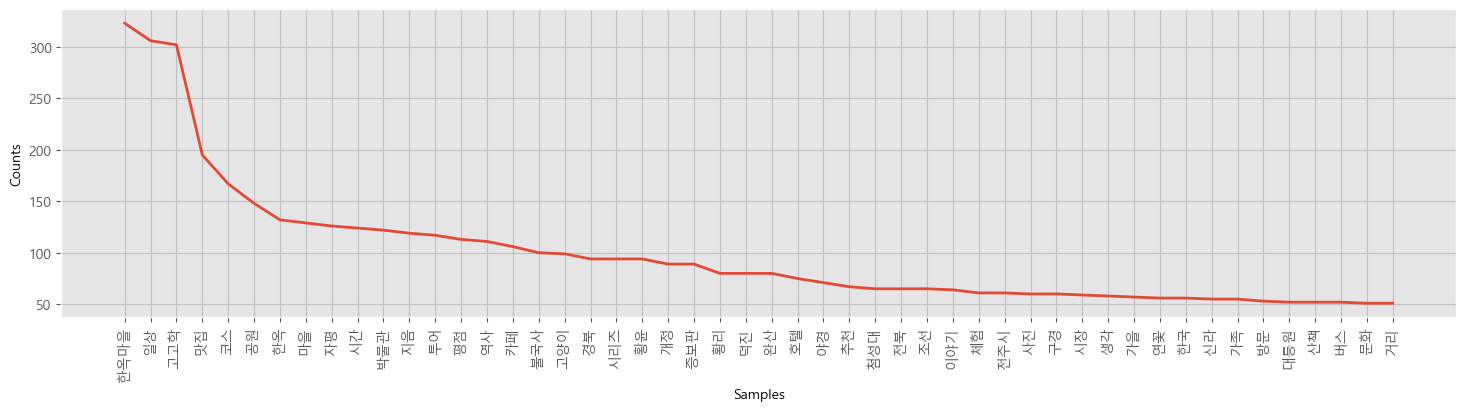

In [89]:
naver_text = Text(nouns_list)
plt.figure(figsize=(18,4))
naver_text.plot(50)
plt.show()

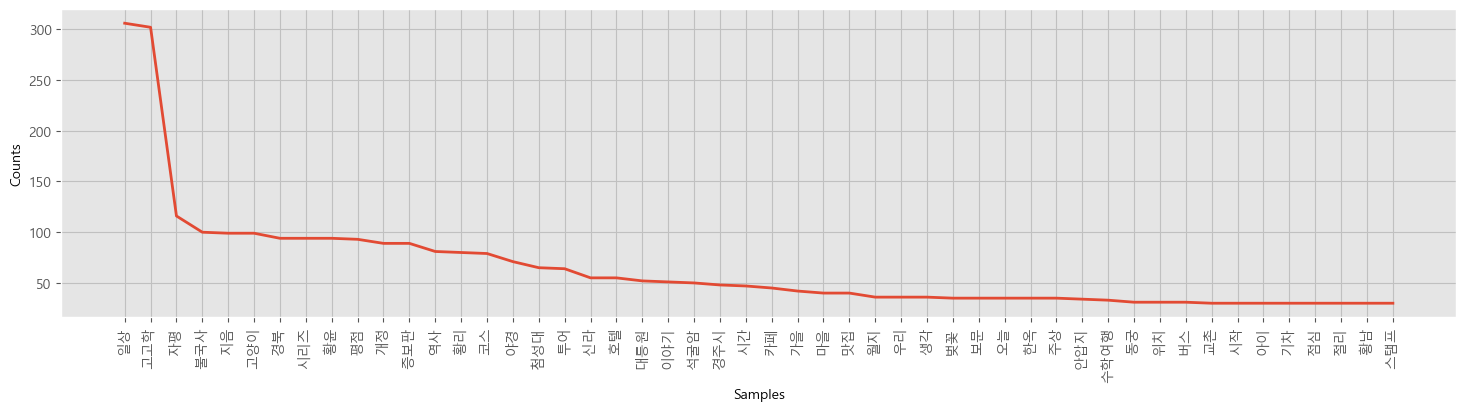

In [100]:
gj_df = df_nouns.loc[df_nouns['query']=='경주 여행', ['token']]
gj_list = gj_df.values.reshape(-1).tolist()
gj_text = Text(gj_list)
plt.figure(figsize=(18,4))
gj_text.plot(50)
plt.show()

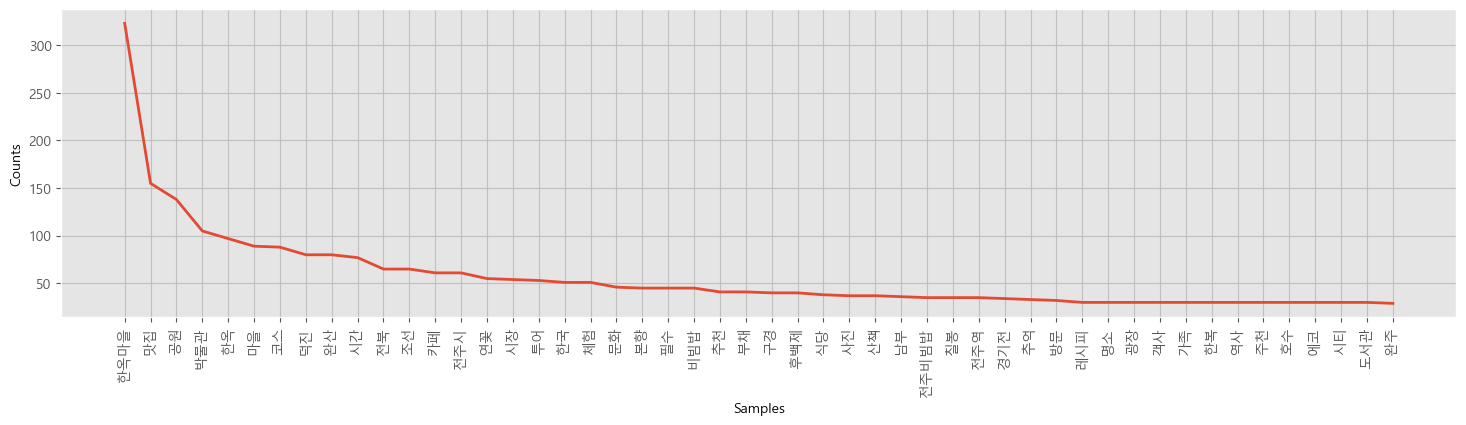

In [101]:
jj_df = df_nouns.loc[df_nouns['query']=='전주 여행', ['token']]
jj_list = jj_df.values.reshape(-1).tolist()
jj_text = Text(jj_list)
plt.figure(figsize=(18,4))
jj_text.plot(50)
plt.show()

In [109]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [108]:
import cv2
import matplotlib.pyplot as plt

In [111]:
img = Image.open('data/korea-house-black-fill.png')
mask_raw = np.array(img)

mask = mask_raw.copy()
if mask.ndim == 3 and mask.shape[2] == 4:
    transparent_area = (mask[:, :, 3] == 0)
    mask[transparent_area] = [255, 255, 255, 255]

In [152]:
from matplotlib import colormaps
list(colormaps)

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'magma_r',
 'inferno_r',
 'plasma_r',
 'viridis_r',
 'cividis_r',
 'twilight_r',
 'twilight

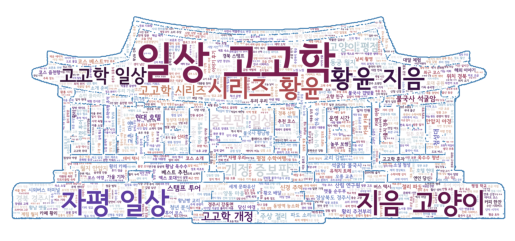

In [182]:
gj_noun = ' '.join(gj_list)

wordcloud = WordCloud(font_path='C:/Windows/Fonts/SeoulNamsanEB.ttf',
                      width=800,
                      height=400,
                      background_color='white',
                      max_words=1000,
                      relative_scaling=0.5,
                      contour_width=2,
                      contour_color='steelblue',
                      colormap='twilight_shifted',
                      mask=mask
                     )
wordcloud.generate(gj_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [183]:
wordcloud.to_file('경주.png')

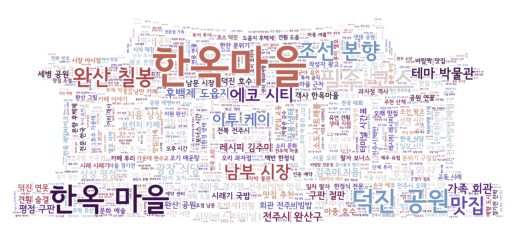

In [180]:
jj_noun = ' '.join(jj_list)

wordcloud = WordCloud(font_path='C:/Windows/Fonts/SeoulNamsanEB.ttf',
                      width=800,
                      height=400,
                      background_color='white',
                      max_words=1000,
                      relative_scaling=0.5,
                      colormap='twilight_shifted',
                      mask=mask
                     )
wordcloud.generate(jj_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [181]:
wordcloud.to_file('전주.png')

## 6. 워드 임베딩

In [127]:
df = pd.read_csv('data/naver_ex.csv', encoding='cp949')

In [129]:
text_list = df['total_text'].values.tolist()

In [133]:
mecab = MeCab()

texts = []

for text in text_list:
    noun_list = mecab.nouns(text)
    noun_list = [word for word, tag in mecab.pos(text) if tag in ('NNG','NNP')]
    texts.append(noun_list)

In [135]:
from gensim.models import Word2Vec

In [184]:
model = Word2Vec(
    sentences=texts,
    window=10,
    min_count=20,
    workers=4,
    sg=1
)

In [185]:
print(model.wv.index_to_key[:30])

['여행', '전주', '경주', '한옥마을', '일상', '고고학', '곳', '길', '책', '알라딘', '맛집', '코스', '공원', '한옥', '마을', '자평', '시간', '박물관', '지음', '투어', '평점', '역사', '카페', '불국사', '고양이', '황윤', '시리즈', '경북', '증보판', '개정']


In [186]:
model.wv.most_similar('여행', topn=10) 

[('서재', 0.7819598317146301),
 ('계획', 0.7750083804130554),
 ('동국', 0.7689283490180969),
 ('동네', 0.7618918418884277),
 ('군산', 0.7529844045639038),
 ('여행지', 0.7295792102813721),
 ('사람', 0.7198282480239868),
 ('일', 0.7141818404197693),
 ('퇴근', 0.7061371207237244),
 ('역사', 0.6989064812660217)]